In [3]:
# For AMD GPU use:
# import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # must be set before torch/sentence_transformers imports on this setup

import joblib
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
import torch


MODEL_DIR = "all-roberta-large-v1"
ROUTER_DIR = "trained_routers/trained_svm_classifier.joblib"

device = "cuda" if torch.cuda.is_available() else "cpu"

router = joblib.load(ROUTER_DIR)
find_big_model = joblib.load("trained_routers/high_cost_classifier.joblib")

print(torch.cuda.is_available())

model = SentenceTransformer(MODEL_DIR, device=device)
find_encoder = SentenceTransformer("all-roberta-large-v1", device=device)

df_val = pd.read_csv("dataset/final_binary/val.csv")
df_test = pd.read_csv("dataset/final_binary/test.csv")

X_validation = df_val["question"].tolist()
X_test = df_test["question"].tolist()


X_val_embeddings = model.encode(X_validation, batch_size=64, show_progress_bar=True)
X_test_embeddings = model.encode(X_test, batch_size=64, show_progress_bar=True)

df_val["complex"] = (df_val["slm_accuracy_fraction"] < 0.75).astype(int)
df_test["complex"] = (df_test["slm_accuracy_fraction"] < 0.75).astype(int)

y_val = df_val["complex"].values
y_test = df_test["complex"].values

y_pred_score_validation = router.predict_proba(X_val_embeddings)
y_pred_validation = (y_pred_score_validation[:, 1] >= 0.5).astype(int)

true_simple = (y_val == 0)
true_complex = (y_val == 1)
pred_simple = (y_pred_validation == 0)
pred_complex = (y_pred_validation == 1)

p_simple_simple = int((true_simple & pred_simple).sum())
p_simple_complex = int((true_simple & pred_complex).sum())
p_complex_simple = int((true_complex & pred_simple).sum())
p_complex_complex = int((true_complex & pred_complex).sum())

print("Validation complexity-label breakdown:")
print(f"true simple -> predicted simple: {p_simple_simple}")
print(f"true simple -> predicted complex: {p_simple_complex}")
print(f"true complex -> predicted simple: {p_complex_simple}")
print(f"true complex -> predicted complex: {p_complex_complex}")

# Configure selected models here.
SLM_MODEL = "qwen2_5_7b"
LLM_MODEL = "gpt5"

def _model_cols(model_name):
    return {
        "correct": f"is_correct_{model_name}",
        "latency": f"latency_{model_name}",
        "input_tokens": f"input_tokens_{model_name}",
        "output_tokens": f"output_tokens_{model_name}",
    }

def _validate_model_cols(df, model_name):
    cols = _model_cols(model_name)
    missing = [col for col in cols.values() if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns for model '{model_name}': {missing}")
    return cols

slm_cols = _validate_model_cols(df_val, SLM_MODEL)
llm_cols = _validate_model_cols(df_val, LLM_MODEL)

slm_can = (pd.to_numeric(df_val[slm_cols["correct"]], errors="coerce").fillna(0).to_numpy() > 0.5).astype(int)
llm_can = (pd.to_numeric(df_val[llm_cols["correct"]], errors="coerce").fillna(0).to_numpy() > 0.5).astype(int)

print("\nOf predicted simple:")
print(f"SLM ({SLM_MODEL}) can solve: {int(slm_can[pred_simple].sum())} / {int(pred_simple.sum())}")
print(f"LLM ({LLM_MODEL}) can solve: {int(llm_can[pred_simple].sum())} / {int(pred_simple.sum())}")

print("\nOf predicted complex:")
print(f"SLM ({SLM_MODEL}) can solve: {int(slm_can[pred_complex].sum())} / {int(pred_complex.sum())}")
print(f"LLM ({LLM_MODEL}) can solve: {int(llm_can[pred_complex].sum())} / {int(pred_complex.sum())}")

q_s_complex = int(slm_can[pred_complex].sum()) / int(pred_complex.sum()) if pred_complex.sum() > 0 else 0
q_s_simple = int(slm_can[pred_simple].sum()) / int(pred_simple.sum()) if pred_simple.sum() > 0 else 0
q_l_complex = int(llm_can[pred_complex].sum()) / int(pred_complex.sum()) if pred_complex.sum() > 0 else 0
q_l_simple = int(llm_can[pred_simple].sum()) / int(pred_simple.sum()) if pred_simple.sum() > 0 else 0


print("\nEstimated probabilities:")
print(f"Q(SLM solves | predicted complex) = {q_s_complex:.2f}")
print(f"Q(SLM solves | predicted simple) = {q_s_simple:.2f}")
print(f"Q(LLM solves | predicted complex) = {q_l_complex:.2f}")
print(f"Q(LLM solves | predicted simple) = {q_l_simple:.2f}")

# Averages for the exact four probability scenarios above.
def _cond_avg(df, mask, model_cols):
    mask = np.asarray(mask, dtype=bool)
    if len(mask) != len(df):
        raise ValueError(f"Mask length {len(mask)} does not match dataframe length {len(df)}")
    n = int(mask.sum())
    if n == 0:
        return n, float("nan"), float("nan"), float("nan")
    avg_latency = pd.to_numeric(df.loc[mask, model_cols["latency"]], errors="coerce").mean()
    avg_input = pd.to_numeric(df.loc[mask, model_cols["input_tokens"]], errors="coerce").mean()
    avg_output = pd.to_numeric(df.loc[mask, model_cols["output_tokens"]], errors="coerce").mean()
    return n, avg_latency, avg_input, avg_output

llm_can_bool = llm_can.astype(bool)
slm_can_bool = slm_can.astype(bool)

masks = [
    ("Q(SLM solves | predicted complex)", pred_complex & slm_can_bool, slm_cols),
    ("Q(SLM solves | predicted simple)", pred_simple & slm_can_bool, slm_cols),
    ("Q(LLM solves | predicted complex)", pred_complex & llm_can_bool, llm_cols),
    ("Q(LLM solves | predicted simple)", pred_simple & llm_can_bool, llm_cols),
]

q_s_complex_metrics = _cond_avg(df_val, pred_complex & slm_can_bool, slm_cols)
q_s_simple_metrics = _cond_avg(df_val, pred_simple & slm_can_bool, slm_cols)
q_l_complex_metrics = _cond_avg(df_val, pred_complex & llm_can_bool, llm_cols)
q_l_simple_metrics = _cond_avg(df_val, pred_simple & llm_can_bool, llm_cols)

# Compute average input/output tokens and latency for the total of selected llm and slm.
slm_latency = pd.to_numeric(df_val[slm_cols["latency"]], errors="coerce").mean()
slm_input_tokens = pd.to_numeric(df_val[slm_cols["input_tokens"]], errors="coerce").mean()
slm_output_tokens = pd.to_numeric(df_val[slm_cols["output_tokens"]], errors="coerce").mean()
llm_latency = pd.to_numeric(df_val[llm_cols["latency"]], errors="coerce").mean()
llm_input_tokens = pd.to_numeric(df_val[llm_cols["input_tokens"]], errors="coerce").mean()
llm_output_tokens = pd.to_numeric(df_val[llm_cols["output_tokens"]], errors="coerce").mean()

print("\nOverall averages across all validation samples:")
print(f"SLM avg latency: {slm_latency}")
print(f"LLM avg latency: {llm_latency}")
print(f"SLM avg input tokens: {slm_input_tokens}")
print(f"LLM avg input tokens: {llm_input_tokens}")
print(f"SLM avg output tokens: {slm_output_tokens}")
print(f"LLM avg output tokens: {llm_output_tokens}")


2026-05-22 15:56:24.406006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-22 15:56:25.007276: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


True


Batches:   0%|          | 0/86 [00:00<?, ?it/s]

Batches:   0%|          | 0/86 [00:00<?, ?it/s]

Validation complexity-label breakdown:
true simple -> predicted simple: 1800
true simple -> predicted complex: 779
true complex -> predicted simple: 805
true complex -> predicted complex: 2080

Of predicted simple:
SLM (qwen2_5_7b) can solve: 1972 / 2605
LLM (gpt5) can solve: 2427 / 2605

Of predicted complex:
SLM (qwen2_5_7b) can solve: 1128 / 2859
LLM (gpt5) can solve: 2366 / 2859

Estimated probabilities:
Q(SLM solves | predicted complex) = 0.39
Q(SLM solves | predicted simple) = 0.76
Q(LLM solves | predicted complex) = 0.83
Q(LLM solves | predicted simple) = 0.93

Overall averages across all validation samples:
SLM avg latency: 3.1007189569935947
LLM avg latency: 23.806206206190154
SLM avg input tokens: 179.08912884333822
LLM avg input tokens: 154.00091508052708
SLM avg output tokens: 461.15592972181554
LLM avg output tokens: 1897.1786237188874


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

GPT5_INPUT_PRICE_PER_1M = 1.25
GPT5_OUTPUT_PRICE_PER_1M = 10.0

# p = P(complex | x) is produced by the classifier.
# E[C | a, x] = c_a + lambda * t_a + C_err * (1 - q_a(x))
LAMBDA_LATENCY = 0.10
MU_COST = 100 # Make the units from dollars to cents
C_ERR = 13

MANUAL_Q_S_SIMPLE = q_s_simple
MANUAL_Q_S_COMPLEX = q_s_complex
MANUAL_Q_L_SIMPLE = q_l_simple
MANUAL_Q_L_COMPLEX = q_l_complex


def error_cost(cost, latency, q, lambd=LAMBDA_LATENCY, mu=MU_COST, c_err=C_ERR):
    return cost*mu + lambd * latency + c_err * (1 - q)

def compute_expected_cost(input_tokens, output_tokens):
    total_cost = (input_tokens / 1_000_000) * GPT5_INPUT_PRICE_PER_1M + (output_tokens / 1_000_000) * GPT5_OUTPUT_PRICE_PER_1M
    # print(total_cost)
    return total_cost

def compute_qs(p):
    qs = (1-p) * MANUAL_Q_S_SIMPLE + p * MANUAL_Q_S_COMPLEX
    return qs

def compute_ql(p):
    ql = (1-p) * MANUAL_Q_L_SIMPLE + p * MANUAL_Q_L_COMPLEX
    return ql

def avg_ql():
    total = int(pred_complex.sum()) + int(pred_simple.sum())
    if total == 0:
        return 0.0
    return (int(pred_complex.sum()) * q_l_complex + int(pred_simple.sum()) * q_l_simple) / total

def avg_qs():
    total = int(pred_complex.sum()) + int(pred_simple.sum())
    if total == 0:
        return 0.0
    return (int(pred_complex.sum()) * q_s_complex + int(pred_simple.sum()) * q_s_simple) / total
    

def bayesian_decision_2path(p, lambd=LAMBDA_LATENCY, mu=MU_COST, cerr=C_ERR):
    p = float(np.asarray(p).reshape(-1)[-1])
    total_cost_small = 0
    total_cost_big = compute_expected_cost(llm_input_tokens, llm_output_tokens)
    ql = compute_ql(p)
    qs = compute_qs(p)
    error_big = error_cost(total_cost_big, llm_latency, ql, lambd=lambd, mu=mu, c_err=cerr)
    error_small = error_cost(total_cost_small, slm_latency, qs, lambd=lambd, mu=mu, c_err=cerr)
    if error_big < error_small:
        return "big"
    else:
        return "small"

def compute_threshold(C_ERR):
    delta_c = (compute_expected_cost(llm_input_tokens, llm_output_tokens) - 0) * MU_COST + LAMBDA_LATENCY * (llm_latency - slm_latency)
    d_simple = q_l_simple - q_s_simple
    d_complex = q_l_complex - q_s_complex
    return ((delta_c / C_ERR) - d_simple) / (d_complex - d_simple)

threshhold = compute_threshold(C_ERR)

print(threshhold)

0.511028459452565


In [5]:
# Decision loop using the existing bayesian_decision_2path from the previous cell
router_performance_data = []
best_route_performance_data = []
high_cost_clf_performance_data = []

if "SLM_MODEL" not in globals():
    SLM_MODEL = "llama3_1_8b"
if "LLM_MODEL" not in globals():
    LLM_MODEL = "gpt5"

def _model_cols(model_name):
    return {
        "correct": f"is_correct_{model_name}",
        "latency": f"latency_{model_name}",
        "input_tokens": f"input_tokens_{model_name}",
        "output_tokens": f"output_tokens_{model_name}",
    }

def _to_bool(x):
    x_num = pd.to_numeric(pd.Series([x]), errors="coerce").iloc[0]
    return bool(pd.notna(x_num) and float(x_num) > 0.5)

slm_cols = _model_cols(SLM_MODEL)
llm_cols = _model_cols(LLM_MODEL)
required_cols = set(slm_cols.values()) | set(llm_cols.values())
missing_cols = sorted([c for c in required_cols if c not in df_test.columns])
if missing_cols:
    raise KeyError(f"Missing required test columns: {missing_cols}")

df_test_eval = df_test.reset_index(drop=True).copy()
test_probs = router.predict_proba(X_test_embeddings)[:, 1]

# Pre-encode all questions for the high cost classifier to avoid re-encoding per row
test_questions = df_test_eval["question"].tolist()
high_cost_embeddings = find_encoder.encode(test_questions, normalize_embeddings=True, show_progress_bar=True)
# high_cost_predictions = find_big_model.predict(high_cost_embeddings)
high_cost_predictions = [0] * len(test_questions)

for data in [router_performance_data, best_route_performance_data, high_cost_clf_performance_data]:
    for i, row in df_test_eval.iterrows():
        qid = row["id"] if "id" in row.index else i
        p_prob = float(test_probs[i])

        slm_correct_row = int(_to_bool(row[slm_cols["correct"]]))
        llm_correct_row = int(_to_bool(row[llm_cols["correct"]]))

        if data is router_performance_data:
            decision = bayesian_decision_2path(p_prob)

        elif data is high_cost_clf_performance_data:
            # If high cost classifier predicts 1 (high cost query), route to SLM.
            # Otherwise fall through to the normal bayesian decision.
            if high_cost_predictions[i] == 1:
                decision = "small"
            else:
                decision = bayesian_decision_2path(p_prob)

        else:
            # Oracle: use SLM when it answers correctly (it's free), else LLM.
            # Decision is independent of LAMBDA_LATENCY and C_ERR.
            decision = "small" if slm_correct_row else "big"

        slm_latency_row = pd.to_numeric(pd.Series([row[slm_cols["latency"]]]), errors="coerce").iloc[0]
        slm_input_tokens_row = pd.to_numeric(pd.Series([row[slm_cols["input_tokens"]]]), errors="coerce").iloc[0]
        slm_output_tokens_row = pd.to_numeric(pd.Series([row[slm_cols["output_tokens"]]]), errors="coerce").iloc[0]
        llm_latency_row = pd.to_numeric(pd.Series([row[llm_cols["latency"]]]), errors="coerce").iloc[0]
        llm_input_tokens_row = pd.to_numeric(pd.Series([row[llm_cols["input_tokens"]]]), errors="coerce").iloc[0]
        llm_output_tokens_row = pd.to_numeric(pd.Series([row[llm_cols["output_tokens"]]]), errors="coerce").iloc[0]

        if decision == "small":
            latency = slm_latency_row
            in_tokens = slm_input_tokens_row
            out_tokens = slm_output_tokens_row
            correct_answer = slm_correct_row
            actual_cost = 0.0
            error = error_cost(actual_cost, latency, correct_answer)
            predicted_cost = 0.0
            predicted_latency = slm_latency
            router_q = compute_qs(p_prob)
        else:
            latency = llm_latency_row
            in_tokens = llm_input_tokens_row
            out_tokens = llm_output_tokens_row
            correct_answer = llm_correct_row
            actual_cost = compute_expected_cost(in_tokens, out_tokens)
            error = error_cost(actual_cost, latency, correct_answer)
            predicted_cost = compute_expected_cost(llm_input_tokens, llm_output_tokens)
            predicted_latency = llm_latency
            router_q = compute_ql(p_prob)

        error_arr = np.asarray(error).reshape(-1)
        error_scalar = error_arr[0] if error_arr.size > 0 else np.nan

        data.append({
            "id": qid,
            "p": p_prob,
            "decision": decision,
            "correct_answer": int(correct_answer),
            "total_latency": float(latency) if pd.notna(latency) else float("nan"),
            "input_tokens": float(in_tokens) if pd.notna(in_tokens) else float("nan"),
            "output_tokens": float(out_tokens) if pd.notna(out_tokens) else float("nan"),
            "actual_cost": float(actual_cost) if pd.notna(actual_cost) else float("nan"),
            "predicted_cost": float(predicted_cost) if pd.notna(predicted_cost) else float("nan"),
            "predicted_latency": float(predicted_latency) if pd.notna(predicted_latency) else float("nan"),
            "error_cost": float(error_scalar) if pd.notna(error_scalar) else float("nan"),
            "router_q": float(router_q) if pd.notna(router_q) else float("nan"),
        })

# Compare avg performance of router to small and big performance
avg_latency_slm = pd.to_numeric(df_test_eval[slm_cols["latency"]], errors="coerce").mean()
avg_input_tokens_slm = pd.to_numeric(df_test_eval[slm_cols["input_tokens"]], errors="coerce").mean()
avg_output_tokens_slm = pd.to_numeric(df_test_eval[slm_cols["output_tokens"]], errors="coerce").mean()

# Actual per-sample error for SLM baseline: q=1 if correct, 0 if wrong
_slm_lat_arr = pd.to_numeric(df_test_eval[slm_cols["latency"]], errors="coerce").values
_slm_q_arr = (pd.to_numeric(df_test_eval[slm_cols["correct"]], errors="coerce").fillna(0) > 0.5).astype(int).values
avg_actual_error_slm = float(np.nanmean(error_cost(0.0, _slm_lat_arr, _slm_q_arr)))

avg_latency_llm = pd.to_numeric(df_test_eval[llm_cols["latency"]], errors="coerce").mean()
avg_input_tokens_llm = pd.to_numeric(df_test_eval[llm_cols["input_tokens"]], errors="coerce").mean()
avg_output_tokens_llm = pd.to_numeric(df_test_eval[llm_cols["output_tokens"]], errors="coerce").mean()
avg_cost_llm = compute_expected_cost(avg_input_tokens_llm, avg_output_tokens_llm)

# Actual per-sample error for LLM baseline: q=1 if correct, 0 if wrong
_llm_lat_arr = pd.to_numeric(df_test_eval[llm_cols["latency"]], errors="coerce").values
_llm_in_arr = pd.to_numeric(df_test_eval[llm_cols["input_tokens"]], errors="coerce").values
_llm_out_arr = pd.to_numeric(df_test_eval[llm_cols["output_tokens"]], errors="coerce").values
_llm_cost_arr = np.array([compute_expected_cost(inp, out) for inp, out in zip(_llm_in_arr, _llm_out_arr)])
_llm_q_arr = (pd.to_numeric(df_test_eval[llm_cols["correct"]], errors="coerce").fillna(0) > 0.5).astype(int).values
avg_actual_error_llm = float(np.nanmean(error_cost(_llm_cost_arr, _llm_lat_arr, _llm_q_arr)))

def _summarise(perf_data, label):
    latency_s  = pd.to_numeric(pd.Series([r["total_latency"]  for r in perf_data]), errors="coerce")
    in_tok_s   = pd.to_numeric(pd.Series([r["input_tokens"]   for r in perf_data]), errors="coerce")
    out_tok_s  = pd.to_numeric(pd.Series([r["output_tokens"]  for r in perf_data]), errors="coerce")
    error_s    = pd.to_numeric(pd.Series([r["error_cost"]     for r in perf_data]), errors="coerce")
    correct_s  = pd.to_numeric(pd.Series([r["correct_answer"] for r in perf_data]), errors="coerce")
    cost_s     = pd.to_numeric(pd.Series([r["actual_cost"]    for r in perf_data]), errors="coerce")
    decision_s = pd.Series([r["decision"] for r in perf_data])
    is_big     = decision_s == "big"
    is_small   = decision_s == "small"
    n_big      = int(is_big.sum())
    n          = len(perf_data)

    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")
    print(f"Avg latency:       {latency_s.mean():.2f} s")
    print(f"Avg input tokens:  {in_tok_s.mean():.2f}")
    print(f"Avg output tokens: {out_tok_s.mean():.2f}")
    print(f"Avg cost:          {cost_s.mean() * MU_COST:.4f} Cents")
    print(f"Avg error:         {error_s.mean():.2f}")
    print(f"Avg correct:       {correct_s.mean():.2%}")
    print(f"Big decisions:     {n_big} / {n}  ({n_big/n*100:.2f}%)")
    if is_big.any():
        print(f"  Latency (big):   {latency_s[is_big].mean():.2f} s")
        print(f"  Cost (big):      {cost_s[is_big].mean() * MU_COST:.4f} Cents")
    if is_small.any():
        print(f"  Latency (small): {latency_s[is_small].mean():.2f} s")

router_latency_series = pd.to_numeric(pd.Series([row["total_latency"] for row in router_performance_data]), errors="coerce")
router_input_tokens_series = pd.to_numeric(pd.Series([row["input_tokens"] for row in router_performance_data]), errors="coerce")
router_output_tokens_series = pd.to_numeric(pd.Series([row["output_tokens"] for row in router_performance_data]), errors="coerce")
router_error_series = pd.to_numeric(pd.Series([row["error_cost"] for row in router_performance_data]), errors="coerce")
router_correct_series = pd.to_numeric(pd.Series([row["correct_answer"] for row in router_performance_data]), errors="coerce")
router_num_big_decisions = (pd.Series([row["decision"] for row in router_performance_data]) == "big").sum()
router_q_series = pd.to_numeric(pd.Series([row["router_q"] for row in router_performance_data]), errors="coerce")
router_actual_cost_series = pd.to_numeric(pd.Series([row["actual_cost"] for row in router_performance_data]), errors="coerce")
router_predicted_cost_series = pd.to_numeric(pd.Series([row["predicted_cost"] for row in router_performance_data]), errors="coerce")
router_predicted_latency_series = pd.to_numeric(pd.Series([row["predicted_latency"] for row in router_performance_data]), errors="coerce")

router_decision_series = pd.Series([row["decision"] for row in router_performance_data])
router_is_big = (router_decision_series == "big")
router_is_small = (router_decision_series == "small")

avg_latency_router = router_latency_series.mean()
avg_input_tokens_router = router_input_tokens_series.mean()
avg_output_tokens_router = router_output_tokens_series.mean()
avg_cost_router = router_actual_cost_series.mean()
avg_error_router = router_error_series.mean()
avg_correct_answer_router = router_correct_series.mean()
avg_q_router = router_q_series.mean()

best_route_latency_series = pd.to_numeric(pd.Series([row["total_latency"] for row in best_route_performance_data]), errors="coerce")
best_route_input_tokens_series = pd.to_numeric(pd.Series([row["input_tokens"] for row in best_route_performance_data]), errors="coerce")
best_route_output_tokens_series = pd.to_numeric(pd.Series([row["output_tokens"] for row in best_route_performance_data]), errors="coerce")
best_route_error_series = pd.to_numeric(pd.Series([row["error_cost"] for row in best_route_performance_data]), errors="coerce")
best_route_correct_series = pd.to_numeric(pd.Series([row["correct_answer"] for row in best_route_performance_data]), errors="coerce")
best_route_num_big_decisions = (pd.Series([row["decision"] for row in best_route_performance_data]) == "big").sum()
best_route_actual_cost_series = pd.to_numeric(pd.Series([row["actual_cost"] for row in best_route_performance_data]), errors="coerce")

avg_latency_best_route = best_route_latency_series.mean()
avg_input_tokens_best_route = best_route_input_tokens_series.mean()
avg_output_tokens_best_route = best_route_output_tokens_series.mean()
avg_cost_best_route = best_route_actual_cost_series.mean()
avg_error_best_route = best_route_error_series.mean()
avg_correct_answer_best_route = best_route_correct_series.mean()

router_big_share = router_is_big.mean()
router_small_share = router_is_small.mean()
router_latency_big = router_latency_series[router_is_big].mean()
router_latency_small = router_latency_series[router_is_small].mean()
router_cost_big = router_actual_cost_series[router_is_big].mean()
router_cost_small = router_actual_cost_series[router_is_small].mean()
router_tokens_in_big = router_input_tokens_series[router_is_big].mean()
router_tokens_in_small = router_input_tokens_series[router_is_small].mean()
router_tokens_out_big = router_output_tokens_series[router_is_big].mean()
router_tokens_out_small = router_output_tokens_series[router_is_small].mean()
reconstructed_latency = (router_big_share * router_latency_big) + (router_small_share * router_latency_small)
reconstructed_cost = (router_big_share * router_cost_big) + (router_small_share * router_cost_small)

# Counterfactuals on exact routed subsets
llm_latency_on_big_subset = pd.to_numeric(df_test_eval.loc[router_is_big.values, llm_cols["latency"]], errors="coerce").mean()
slm_latency_on_small_subset = pd.to_numeric(df_test_eval.loc[router_is_small.values, slm_cols["latency"]], errors="coerce").mean()
llm_cost_on_big_subset = compute_expected_cost(
    pd.to_numeric(df_test_eval.loc[router_is_big.values, llm_cols["input_tokens"]], errors="coerce").mean(),
    pd.to_numeric(df_test_eval.loc[router_is_big.values, llm_cols["output_tokens"]], errors="coerce").mean(),
)

print("SLM Performance")
print(f"Selected SLM: {SLM_MODEL}")
print(f"Avg latency (test): {avg_latency_slm:.2f} seconds")
print(f"Avg latency (validation): {slm_latency:.2f} seconds")
print(f"Avg input tokens: {avg_input_tokens_slm:.2f}")
print(f"Avg output tokens: {avg_output_tokens_slm:.2f}")
print(f"Avg actual error: {avg_actual_error_slm:.4f}")
slm_correct_test = pd.to_numeric(df_test_eval[slm_cols["correct"]], errors="coerce").fillna(0)
print(f"Avg correct answer: {(slm_correct_test > 0.5).mean():.2%}")

print("\nLLM Performance")
print(f"Selected LLM: {LLM_MODEL}")
print(f"Avg latency (test): {avg_latency_llm:.2f} seconds")
print(f"Avg latency (validation): {llm_latency:.2f} seconds")
print(f"Avg input tokens (test): {avg_input_tokens_llm:.2f}")
print(f"Avg input tokens (validation): {llm_input_tokens:.2f}")
print(f"Avg output tokens (test): {avg_output_tokens_llm:.2f}")
print(f"Avg output tokens (validation): {llm_output_tokens:.2f}")
print(f"Avg cost (test): {avg_cost_llm * MU_COST:.4f} Cents")
print(f"Avg cost (validation): {compute_expected_cost(llm_input_tokens, llm_output_tokens) * MU_COST:.4f} Cents")
print(f"Avg actual error: {avg_actual_error_llm:.2f}")
llm_correct_test = pd.to_numeric(df_test_eval[llm_cols["correct"]], errors="coerce").fillna(0)
print(f"Avg correct answer: {(llm_correct_test > 0.5).mean():.2%}")

print("\nRouter Performance (no high-cost classifier)")
print(f"Avg latency: {avg_latency_router:.2f} seconds")
print(f"Avg input tokens: {avg_input_tokens_router:.2f}")
print(f"Avg output tokens: {avg_output_tokens_router:.2f}")
print(f"Avg cost: {avg_cost_router * MU_COST:.4f} Cents")
print(f"Avg actual error: {avg_error_router:.2f}")
print(f"Avg correct answer: {avg_correct_answer_router:.2%}")
print(f"Number of big decisions: {router_num_big_decisions} / {len(router_performance_data)} = {router_num_big_decisions / len(router_performance_data):.2%}")
print(f"Big share: {router_big_share:.3f}, Small share: {router_small_share:.3f}")
print(f"Latency by decision (small/big): {router_latency_small:.2f}s / {router_latency_big:.2f}s")
print(f"Cost by decision (small/big): {router_cost_small * MU_COST:.4f} / {router_cost_big * MU_COST:.4f} Cents")
print(f"Input tokens by decision (small/big): {router_tokens_in_small:.2f} / {router_tokens_in_big:.2f}")
print(f"Output tokens by decision (small/big): {router_tokens_out_small:.2f} / {router_tokens_out_big:.2f}")
print(f"Reconstructed avg latency/cost: {reconstructed_latency:.2f}s / {reconstructed_cost * MU_COST:.4f} Cents")
print(f"LLM latency on routed-big subset: {llm_latency_on_big_subset:.2f}s")
print(f"SLM latency on routed-small subset: {slm_latency_on_small_subset:.2f}s")
print(f"LLM cost on routed-big subset: {llm_cost_on_big_subset * MU_COST:.4f} Cents")

print("\nBest Route Performance")
print(f"Avg latency: {avg_latency_best_route:.2f} seconds")
print(f"Avg input tokens: {avg_input_tokens_best_route:.2f}")
print(f"Avg output tokens: {avg_output_tokens_best_route:.2f}")
print(f"Avg cost: {avg_cost_best_route * MU_COST:.4f} Cents")
print(f"Avg actual error: {avg_error_best_route:.2f}")
print(f"Avg correct answer: {avg_correct_answer_best_route:.2%}")
print(f"Number of big decisions: {best_route_num_big_decisions} / {len(best_route_performance_data)} = {best_route_num_big_decisions / len(best_route_performance_data):.2%}")

# High-cost classifier statistics
_summarise(high_cost_clf_performance_data, "High-Cost Classifier Performance (high_cost=1 → SLM, else → bayesian)")
n_high_cost = int(sum(1 for p in high_cost_predictions if p == 1))
n_low_cost  = int(sum(1 for p in high_cost_predictions if p == 0))
print(f"\nHigh-cost classifier breakdown:")
print(f"  Predicted high-cost (→ SLM):      {n_high_cost} / {len(high_cost_predictions)}  ({n_high_cost/len(high_cost_predictions)*100:.1f}%)")
print(f"  Predicted low-cost  (→ bayesian):  {n_low_cost} / {len(high_cost_predictions)}  ({n_low_cost/len(high_cost_predictions)*100:.1f}%)")

Batches:   0%|          | 0/171 [00:00<?, ?it/s]

SLM Performance
Selected SLM: qwen2_5_7b
Avg latency (test): 3.11 seconds
Avg latency (validation): 3.10 seconds
Avg input tokens: 179.12
Avg output tokens: 463.27
Avg actual error: 6.0848
Avg correct answer: 55.59%

LLM Performance
Selected LLM: gpt5
Avg latency (test): 23.44 seconds
Avg latency (validation): 23.81 seconds
Avg input tokens (test): 154.06
Avg input tokens (validation): 154.00
Avg output tokens (test): 1864.99
Avg output tokens (validation): 1897.18
Avg cost (test): 1.8842 Cents
Avg cost (validation): 1.9164 Cents
Avg actual error: 5.80
Avg correct answer: 87.90%

Router Performance (no high-cost classifier)
Avg latency: 20.65 seconds
Avg input tokens: 165.91
Avg output tokens: 1721.64
Avg cost: 1.5462 Cents
Avg actual error: 6.39
Avg correct answer: 78.66%
Number of big decisions: 2779 / 5465 = 50.85%
Big share: 0.509, Small share: 0.491
Latency by decision (small/big): 2.57s / 38.13s
Cost by decision (small/big): 0.0000 / 3.0406 Cents
Input tokens by decision (small/b

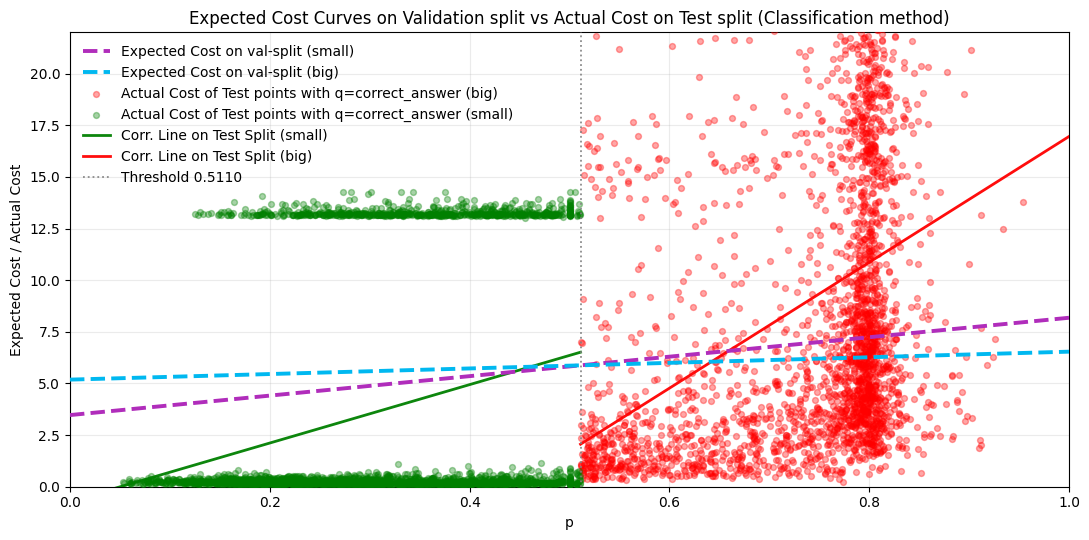

In [9]:
# Plot E[C | L, x] and E[C | S, x] as continuous functions of p in [0, 1].
# Matches the plot style from test_router.ipynb, adapted for the regression router.


p_grid = np.linspace(0.0, 1.0, 1001)

q_l_grid = compute_ql(p_grid)
q_s_grid = compute_qs(p_grid)

llm_cost_mean = compute_expected_cost(llm_input_tokens, llm_output_tokens)

e_l = error_cost(
    llm_cost_mean,
    llm_latency,
    q_l_grid,
    lambd=LAMBDA_LATENCY,
    c_err=C_ERR,
)
e_s = error_cost(
    0.0,
    slm_latency,
    q_s_grid,
    lambd=LAMBDA_LATENCY,
    c_err=C_ERR,
)



cross_idx = int(np.argmin(np.abs(e_l - e_s)))

p_star = float(threshhold) if np.isfinite(threshhold) and 0 <= threshhold <= 1 else float(p_grid[cross_idx])
y_star = float(np.interp(p_star, p_grid, e_l))
p_threshold = float(np.clip(threshhold, 0.0, 1.0)) if np.isfinite(threshhold) else float(np.clip(p_star, 0.0, 1.0))

# Router decisions on test set.
if "test_probs" in globals() and len(test_probs) == len(df_test_eval):
    plot_test_probs = np.asarray(test_probs, dtype=float)
else:
    plot_test_probs = router.predict_proba(X_test_embeddings)[:, 1]

test_points = []
for i, row in df_test_eval.iterrows():
    p_i = float(np.clip(plot_test_probs[i], 0.0, 1.0))
    decision_i = bayesian_decision_2path(p_i, lambd=LAMBDA_LATENCY, cerr=C_ERR)

    slm_correct_row = int(_to_bool(row[slm_cols["correct"]]))
    llm_correct_row = int(_to_bool(row[llm_cols["correct"]]))

    slm_latency_i = pd.to_numeric(pd.Series([row[slm_cols["latency"]]]), errors="coerce").iloc[0]
    llm_latency_i = pd.to_numeric(pd.Series([row[llm_cols["latency"]]]), errors="coerce").iloc[0]
    llm_in_i = pd.to_numeric(pd.Series([row[llm_cols["input_tokens"]]]), errors="coerce").iloc[0]
    llm_out_i = pd.to_numeric(pd.Series([row[llm_cols["output_tokens"]]]), errors="coerce").iloc[0]

    if decision_i == "small":
        e_actual_i = float(error_cost(0.0, slm_latency_i, slm_correct_row, lambd=LAMBDA_LATENCY, c_err=C_ERR))
    else:
        llm_cost_i = compute_expected_cost(llm_in_i, llm_out_i)
        e_actual_i = float(error_cost(llm_cost_i, llm_latency_i, llm_correct_row, lambd=LAMBDA_LATENCY, c_err=C_ERR))

    test_points.append({
        "p": p_i,
        "decision": decision_i,
        "e_actual": e_actual_i,
        "dataset_name": row.get("dataset_name", "unknown"),
    })

test_points_df = pd.DataFrame(test_points)
test_points_df = test_points_df[np.isfinite(test_points_df["p"]) & np.isfinite(test_points_df["e_actual"])].copy()
test_small = test_points_df[test_points_df["decision"] == "small"]
test_big = test_points_df[test_points_df["decision"] == "big"]
test_small_left = test_small[test_small["p"] <= p_threshold].copy()
test_big_right = test_big[test_big["p"] >= p_threshold].copy()

plt.figure(figsize=(11, 5.5))
plt.plot(p_grid, e_s, "--", color="#b02dbb", linewidth=2.8, label="Expected Cost on val-split (small)", zorder=10)
plt.plot(p_grid, e_l, "--", color="#00b8f0", linewidth=2.8, label="Expected Cost on val-split (big)", zorder=10)

plt.scatter(test_big_right["p"], test_big_right["e_actual"], s=18, color="red", alpha=0.35, label="Actual Cost of Test points with q=correct_answer (big)", zorder=3)
plt.scatter(test_small_left["p"], test_small_left["e_actual"], s=18, color="green", alpha=0.35, label="Actual Cost of Test points with q=correct_answer (small)", zorder=3)

# Correlation lines are fit on full decision groups, then clipped at p_threshold for display.
if len(test_small) >= 2:
    coef_small = np.polyfit(test_small["p"].to_numpy(dtype=float), test_small["e_actual"].to_numpy(dtype=float), 1)
    p_line_small = np.linspace(0.0, p_threshold, 200)
    e_line_small = np.polyval(coef_small, p_line_small)
    r_small = float(np.corrcoef(test_small["p"].to_numpy(dtype=float), test_small["e_actual"].to_numpy(dtype=float))[0, 1])
    plt.plot(p_line_small, e_line_small, color="green", linewidth=2.0, alpha=0.95, label=f"Corr. Line on Test Split (small)", zorder=4)

if len(test_big) >= 2:
    coef_big = np.polyfit(test_big["p"].to_numpy(dtype=float), test_big["e_actual"].to_numpy(dtype=float), 1)
    p_line_big = np.linspace(p_threshold, 1.0, 200)
    e_line_big = np.polyval(coef_big, p_line_big)
    r_big = float(np.corrcoef(test_big["p"].to_numpy(dtype=float), test_big["e_actual"].to_numpy(dtype=float))[0, 1])
    plt.plot(p_line_big, e_line_big, color="red", linewidth=2.0, alpha=0.95, label=f"Corr. Line on Test Split (big)", zorder=4)


if np.isfinite(threshhold):
    plt.axvline(p_threshold, color="gray", linestyle=":", linewidth=1.3, alpha=0.9, label=f"Threshold {p_threshold:.4f}", zorder=11)

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 22.0)
plt.xlabel("p")
plt.ylabel("Expected Cost / Actual Cost")
plt.title(f"Expected Cost Curves on Validation split vs Actual Cost on Test split (Classification method)")
plt.legend(frameon=False, loc="upper left")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

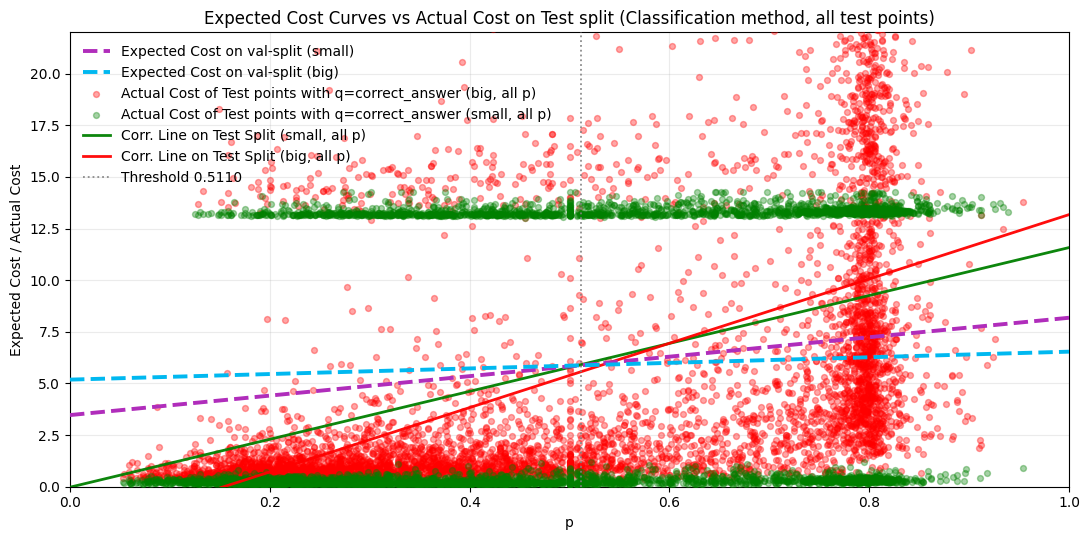

In [7]:
# Same plot as above, but both model actual-cost point clouds span the full p range.
all_test_cost_points = []
for i, row in df_test_eval.iterrows():
    p_i = float(np.clip(plot_test_probs[i], 0.0, 1.0))

    slm_correct_row = int(_to_bool(row[slm_cols["correct"]]))
    llm_correct_row = int(_to_bool(row[llm_cols["correct"]]))

    slm_latency_i = pd.to_numeric(pd.Series([row[slm_cols["latency"]]]), errors="coerce").iloc[0]
    llm_latency_i = pd.to_numeric(pd.Series([row[llm_cols["latency"]]]), errors="coerce").iloc[0]
    llm_in_i = pd.to_numeric(pd.Series([row[llm_cols["input_tokens"]]]), errors="coerce").iloc[0]
    llm_out_i = pd.to_numeric(pd.Series([row[llm_cols["output_tokens"]]]), errors="coerce").iloc[0]

    llm_cost_i = compute_expected_cost(llm_in_i, llm_out_i)
    e_actual_small_i = float(error_cost(0.0, slm_latency_i, slm_correct_row, lambd=LAMBDA_LATENCY, c_err=C_ERR))
    e_actual_big_i = float(error_cost(llm_cost_i, llm_latency_i, llm_correct_row, lambd=LAMBDA_LATENCY, c_err=C_ERR))

    all_test_cost_points.append({
        "p": p_i,
        "e_actual_small": e_actual_small_i,
        "e_actual_big": e_actual_big_i,
        "dataset_name": row.get("dataset_name", "unknown"),
    })

all_test_cost_points_df = pd.DataFrame(all_test_cost_points)
all_test_cost_points_df = all_test_cost_points_df[
    np.isfinite(all_test_cost_points_df["p"])
    & np.isfinite(all_test_cost_points_df["e_actual_small"])
    & np.isfinite(all_test_cost_points_df["e_actual_big"])
].copy()

plt.figure(figsize=(11, 5.5))
plt.plot(p_grid, e_s, "--", color="#b02dbb", linewidth=2.8, label="Expected Cost on val-split (small)", zorder=10)
plt.plot(p_grid, e_l, "--", color="#00b8f0", linewidth=2.8, label="Expected Cost on val-split (big)", zorder=10)

plt.scatter(
    all_test_cost_points_df["p"],
    all_test_cost_points_df["e_actual_big"],
    s=18,
    color="red",
    alpha=0.35,
    label="Actual Cost of Test points with q=correct_answer (big, all p)",
    zorder=3,
)
plt.scatter(
    all_test_cost_points_df["p"],
    all_test_cost_points_df["e_actual_small"],
    s=18,
    color="green",
    alpha=0.35,
    label="Actual Cost of Test points with q=correct_answer (small, all p)",
    zorder=3,
)

p_line_full = np.linspace(0.0, 1.0, 200)
if len(all_test_cost_points_df) >= 2:
    coef_small_all = np.polyfit(
        all_test_cost_points_df["p"].to_numpy(dtype=float),
        all_test_cost_points_df["e_actual_small"].to_numpy(dtype=float),
        1,
    )
    e_line_small_all = np.polyval(coef_small_all, p_line_full)
    r_small_all = float(np.corrcoef(
        all_test_cost_points_df["p"].to_numpy(dtype=float),
        all_test_cost_points_df["e_actual_small"].to_numpy(dtype=float),
    )[0, 1])
    plt.plot(p_line_full, e_line_small_all, color="green", linewidth=2.0, alpha=0.95, label="Corr. Line on Test Split (small, all p)", zorder=4)

    coef_big_all = np.polyfit(
        all_test_cost_points_df["p"].to_numpy(dtype=float),
        all_test_cost_points_df["e_actual_big"].to_numpy(dtype=float),
        1,
    )
    e_line_big_all = np.polyval(coef_big_all, p_line_full)
    r_big_all = float(np.corrcoef(
        all_test_cost_points_df["p"].to_numpy(dtype=float),
        all_test_cost_points_df["e_actual_big"].to_numpy(dtype=float),
    )[0, 1])
    plt.plot(p_line_full, e_line_big_all, color="red", linewidth=2.0, alpha=0.95, label="Corr. Line on Test Split (big, all p)", zorder=4)

if np.isfinite(threshhold):
    plt.axvline(p_threshold, color="gray", linestyle=":", linewidth=1.3, alpha=0.9, label=f"Threshold {p_threshold:.4f}", zorder=11)

y_max = np.nanmax([
    np.nanmax(e_s),
    np.nanmax(e_l),
    all_test_cost_points_df["e_actual_small"].max(),
    all_test_cost_points_df["e_actual_big"].max(),
])

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 22)
plt.xlabel("p")
plt.ylabel("Expected Cost / Actual Cost")
plt.title(f"Expected Cost Curves vs Actual Cost on Test split (Classification method, all test points)")
plt.legend(frameon=False, loc="upper left")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

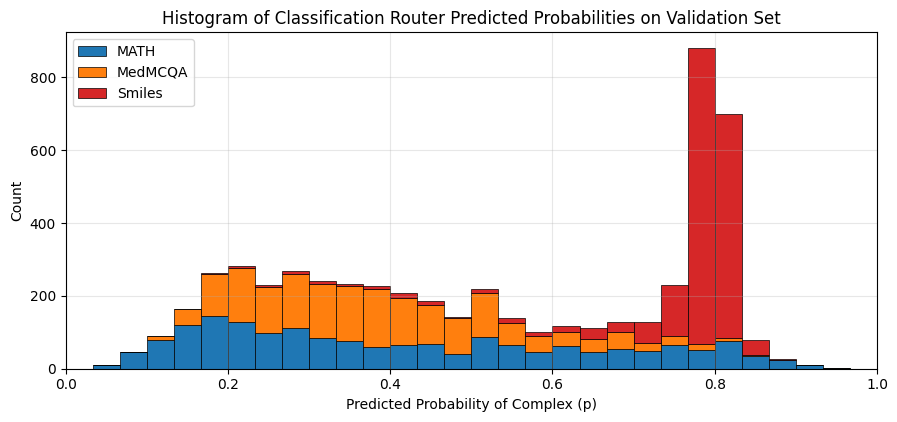

In [8]:
# Histogram of classifier predicted p values on the validation set.
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sentence_transformers import SentenceTransformer

if "ROUTER_DIR" not in globals():
    ROUTER_DIR = "trained_routers/trained_svm_classifier.joblib"

if "router" not in globals():
    router = joblib.load(ROUTER_DIR)

if "df_test" not in globals():
    df_test = pd.read_csv("dataset/final_binary/validation.csv")

if "X_test_embeddings" not in globals() or len(X_test_embeddings) != len(df_test):
    if "MODEL_DIR" not in globals():
        MODEL_DIR = "all-roberta-large-v1"
    if "model" not in globals():
        model = SentenceTransformer(MODEL_DIR)
    X_test_embeddings = model.encode(df_test["question"].tolist(), batch_size=64, show_progress_bar=True)

router_p_test = router.predict_proba(X_test_embeddings)[:, 1]
hist_df = df_test.copy()
hist_df["router_p"] = router_p_test

dataset_specs = [
    ("MATH", "MATH", "#1f77b4"),
    ("Medmcqa", "MedMCQA", "#ff7f0e"),
    ("Smiles", "Smiles", "#d62728"),
]

hist_values = []
hist_labels = []
hist_colors = []
dataset_name = hist_df["dataset_name"].astype(str).str.lower()
for source_name, display_name, color in dataset_specs:
    hist_values.append(hist_df.loc[dataset_name == source_name.lower(), "router_p"].to_numpy())
    hist_labels.append(display_name)
    hist_colors.append(color)

fig, ax = plt.subplots(figsize=(9.08, 4.32))
ax.hist(
    hist_values,
    bins=30,
    range=(0.0, 1.0),
    stacked=True,
    color=hist_colors,
    label=hist_labels,
    edgecolor="black",
    linewidth=0.5,
)
ax.set_title("Histogram of Classification Router Predicted Probabilities on Validation Set")
ax.set_xlabel("Predicted Probability of Complex (p)")
ax.set_ylabel("Count")
ax.set_xlim(0.0, 1.0)
ax.grid(alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()